<a href="https://colab.research.google.com/github/VivanBoy/assistant-rag/blob/main/notebooks/3-assistant-ft/assistant_fine_tune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assistant Fine-Tuné (Basé sur le -Style & Ton de l'Hôtel)**

**Objectif** : Fine-tuner un modèle Mistral 7B Instruct sur la FAQ de l'Hôtel de la Promenade pour qu'il imite le style et le ton spécifiques de l'établissement.

**Contexte**
Dans les notebooks précédents, on a développé un assistant RAG capable de répondre aux questions factuelles à partir de la documentation interne. On souhaite maintenant créer un assistant conversationnel qui répond avec le style caractéristique de l'hôtel, en se basant sur sa FAQ officielle.

**Choix du modèle : Mistral 7B Instruct**
- 7,3 milliards de paramètres, excellent équilibre performance/ressources
- Licence Apache 2.0, utilisation sans restriction
- Performances solides en français et anglais
- Quantifiable en 4-bit pour fine-tuning sur T4 (Colab)

**Approche technique : QLoRA**
- Fine-tuning en 4-bit pour réduire l'empreinte mémoire (~5-6 GB VRAM)
- Adaptateurs LoRA légers (~10 MB) sauvegardés et versionnés
- Modèle de base non modifié, seule la couche d'adaptation est entraînée

**Déploiement prévu**
- Fine-tuning sur Google Colab (GPU T4 gratuit)
- Code et adaptateurs versionnés sur GitHub
- Conteneur Docker avec vLLM pour hébergement sur Koyeb (API OpenAI-compatible)

**Étapes**
1. Configuration de l'environnement (via terminal Colab)
2. Extraction et préparation de la FAQ
3. Création du dataset au format instruction/output
4. Fine-tuning avec QLoRA
5. Sauvegarde des adaptateurs (commit GitHub)
6. Tests comparatifs (modèle de base vs fine-tuné vs FAQ originale)
7. Grille d'évaluation (exactitude, ton, style, fluidité)


## **Configurations de l'environnement**

In [1]:
import os
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
repo_url = "https://github.com/VivanBoy/assistant-rag.git"
!git clone {repo_url}

%cd assistant-rag

Cloning into 'assistant-rag'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 183 (delta 63), reused 134 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 26.41 MiB | 17.73 MiB/s, done.
Resolving deltas: 100% (63/63), done.
/content/assistant-rag


In [3]:
!git switch main
!ls -la

Already on 'main'
Your branch is up to date with 'origin/main'.
total 16644
drwxr-xr-x 8 root root     4096 Mar  2 21:27 .
drwxr-xr-x 1 root root     4096 Mar  2 21:27 ..
-rw-r--r-- 1 root root  4635875 Mar  2 21:27 all_comments_ottawa.csv
drwxr-xr-x 2 root root     4096 Mar  2 21:27 app
drwxr-xr-x 6 root root     4096 Mar  2 21:27 data
drwxr-xr-x 8 root root     4096 Mar  2 21:27 .git
-rw-r--r-- 1 root root      369 Mar  2 21:27 .gitignore
drwxr-xr-x 4 root root     4096 Mar  2 21:27 models
drwxr-xr-x 5 root root     4096 Mar  2 21:27 notebooks
-rw-r--r-- 1 root root      319 Mar  2 21:27 pyproject.toml
-rw-r--r-- 1 root root     4600 Mar  2 21:27 requirements.txt
drwxr-xr-x 4 root root     4096 Mar  2 21:27 src
-rw-r--r-- 1 root root   609534 Mar  2 21:27 UA1_Bloc1_Analyse_Avis_Complet.ipynb
-rw-r--r-- 1 root root    26999 Mar  2 21:27 UA1_Bloc2_RAG_Notebook_Adapted_to_src_data.ipynb
-rw-r--r-- 1 root root 11710514 Mar  2 21:27 ua1_reviews_enriched.csv
-rw-r--r-- 1 root root     3631

## **Installation des Librairies**

In [4]:
# Installation des librairies pour fine-tuning
!pip install -q transformers accelerate peft bitsandbytes trl datasets huggingface_hub
!pip install -q unsloth  # Optionnel mais
!pip install pdfplumber

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 47.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## **Extraction Et Préparation De La FAQ**

In [5]:
# Import des librairies
import pandas as pd
import json
import re
from pathlib import Path
import pdfplumber
import matplotlib.pyplot as plt


import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset
import json


In [6]:
# Définition des chemins
DATA_PART3 = Path("/content/assistant-rag/data/part-3")
MODELS_FT_DIR = Path("/content/assistant-rag/models/2-ft")
MODELS_FT_DIR.mkdir(parents=True, exist_ok=True)

print(f"FAQ source : {DATA_PART3}")
print(f"Dossier de sauvegarde : {MODELS_FT_DIR}")

FAQ source : /content/assistant-rag/data/part-3
Dossier de sauvegarde : /content/assistant-rag/models/2-ft


### **Extraction des textes de la FAQ**

In [7]:
# Extraction du texte de la FAQ
pdf_path = DATA_PART3 / "Partie 3 - FAQ - Hôtel De la Promenade.pdf"

print("Extraction de la FAQ en cours...")
texte_complet = ""

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        texte_page = page.extract_text()
        if texte_page:
            texte_complet += texte_page + "\n"

print(f"Extraction terminée. Longueur du texte : {len(texte_complet)} caractères")
print("\nAperçu du début de la FAQ :")
print(texte_complet[:500])

Extraction de la FAQ en cours...


Extraction terminée. Longueur du texte : 19622 caractères

Aperçu du début de la FAQ :
FAQ — Hôtel De la Promenade
Un nombre limité de questions vous sont proposées, il est recommandé de rajouter des exemples pour
bonifier votre jeu de données.
Q1 : À quelle heure puis-je m'enregistrer à l'hôtel ?
R : Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre
refuge urbain vous attend, fraîchement préparé. Vous arrivez plus tôt et souhaitez déposer vos valises ?
Nous vous accueillons dès midi avec notre service d'enregistrement anticipé moy


### **Parsing de la FAQ**

In [8]:
# Parsing manuel plus robuste
lines = texte_complet.split('\n')
dataset = []
current_q = None
current_r = []
capturing = None

for line in lines:
    line = line.strip()
    if not line:
        continue

    # Détection d'une nouvelle question
    q_match = re.match(r'Q(\d+)\s*:\s*(.*)', line)
    if q_match:
        # Si on était en train de capturer une réponse, on sauvegarde la paire précédente
        if current_q and current_r:
            dataset.append({
                "instruction": current_q,
                "output": ' '.join(current_r).strip()
            })
        # Nouvelle question
        current_q = q_match.group(2).strip()
        current_r = []
        capturing = 'r'
        continue

    # Détection du début d'une réponse
    r_match = re.match(r'R\s*:\s*(.*)', line)
    if r_match:
        current_r.append(r_match.group(1).strip())
        capturing = 'r'
        continue

    # Si on est en train de capturer une réponse, on ajoute la ligne
    if capturing == 'r' and current_r is not None:
        current_r.append(line)

# Ajouter la dernière paire
if current_q and current_r:
    dataset.append({
        "instruction": current_q,
        "output": ' '.join(current_r).strip()
    })



print(f"Nombre de paires Q/R trouvées : {len(dataset)}")

Nombre de paires Q/R trouvées : 30


In [9]:
# Affichage des 5 premières paires
for i, paire in enumerate(dataset[:5]):
    print(f"\n--- Paire {i+1} ---")
    print(f"Q : {paire['instruction']}")
    print(f"R : {paire['output'][:150]}...")


--- Paire 1 ---
Q : À quelle heure puis-je m'enregistrer à l'hôtel ?
R : Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre refuge urbain vous attend, fraîchement préparé. Vo...

--- Paire 2 ---
Q : Puis-je amener mon chien à l'hôtel ?
R : Mais certainement ! Chez nous, les compagnons à quatre pattes font partie de la famille. Nous accueillons vos fidèles amis moyennant des frais de nett...

--- Paire 3 ---
Q : Est-ce que votre hôtel offre le Wi-Fi gratuit ?
R : Absolument ! Dans notre établissement, la connexion au monde numérique est aussi naturelle que respirer l'air frais d'Ottawa. Toutes nos chambres — de...

--- Paire 4 ---
Q : Quelles sont vos politiques d'annulation ?
R : Nous comprenons que les plans peuvent évoluer comme les saisons. Pour nos tarifs flexibles, vous pouvez annuler sans pénalité jusqu'à 24 heures avant ...

--- Paire 5 ---
Q : Le petit-déjeuner est-il inclus dans le prix de la chambre ?
R : L'inclusion du petit-

## **Sauvegarde du Dataset**

In [10]:
# Sauvegarde en format JSONL (un objet JSON par ligne)
with open(MODELS_FT_DIR / "faq_dataset.jsonl", "w") as f:
    for item in dataset:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

# Sauvegarde en format JSON (pour visualisation)
with open(MODELS_FT_DIR / "faq_dataset.json", "w") as f:
    json.dump(dataset, f, indent=2, ensure_ascii=False)

print(f"Dataset sauvegardé dans {MODELS_FT_DIR}")
print(f"Format JSONL : {MODELS_FT_DIR}/faq_dataset.jsonl")
print(f"Format JSON : {MODELS_FT_DIR}/faq_dataset.json")

Dataset sauvegardé dans /content/assistant-rag/models/2-ft
Format JSONL : /content/assistant-rag/models/2-ft/faq_dataset.jsonl
Format JSON : /content/assistant-rag/models/2-ft/faq_dataset.json


In [11]:
# Statistiques
print(f"\nStatistiques :")
print(f"- Nombre de paires : {len(dataset)}")
print(f"- Longueur moyenne des questions : {sum(len(q['instruction']) for q in dataset)/len(dataset):.1f} caractères")
print(f"- Longueur moyenne des réponses : {sum(len(q['output']) for q in dataset)/len(dataset):.1f} caractères")


Statistiques :
- Nombre de paires : 30
- Longueur moyenne des questions : 50.8 caractères
- Longueur moyenne des réponses : 586.3 caractères


## **Fine-Tuning Avec `QLoRA`**




In [12]:
# Vérification du GPU
print(f"GPU disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nom du GPU : {torch.cuda.get_device_name(0)}")
    print(f"Mémoire VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

GPU disponible : True
Nom du GPU : Tesla T4
Mémoire VRAM : 15.64 GB


In [13]:
# Chargement du dataset
dataset_path = MODELS_FT_DIR / "faq_dataset.jsonl"

data = []
with open(dataset_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Conversion au format Hugging Face Dataset
dataset = Dataset.from_list(data)

### **Split Train/Validation (80/20)**

In [14]:
# Split train/validation (80/20)
split_dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(f"Taille du dataset d'entraînement : {len(train_dataset)}")
print(f"Taille du dataset de validation : {len(eval_dataset)}")

# Affichage d'un exemple
print("\nExemple du dataset :")
print(train_dataset[0])

Taille du dataset d'entraînement : 24
Taille du dataset de validation : 6

Exemple du dataset :
{'instruction': 'À quelle heure dois-je libérer ma chambre ?', 'output': "Le départ standard s'effectue à 11h00, heure à laquelle votre chambre retrouve son éclat pour accueillir les prochains visiteurs. Vous souhaitez prolonger votre séjour jusqu'à 14h00 ? Nous proposons un départ tardif moyennant 50 $, vous offrant ainsi quelques heures supplémentaires de tranquillité. Au-delà de cette heure, le tarif d'une nuitée complète s'appliquera. Comme toujours, notre équipe à la réception se fera un plaisir d'accommoder vos besoins dans la mesure du possible."}


**NB:** Les questions de validation (20% du dataset) seront utilisées pour l'évaluation qualitative finale. On comparera manuellement le modèle de base, le modèle fine-tuné et la FAQ originale sur quatre critères, **exactitude, ton, style et fluidité.**

## **`Mistral 7B` - Model & Tokenizer avec `Quantification 4-bit`**

In [15]:
from huggingface_hub import login
login()

In [16]:
# Chargement du modèle et du tokenizer avec quantification 4-bit
model_name_mistral = "mistralai/Mistral-7B-Instruct-v0.3"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("Chargement du tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name_mistral)
tokenizer.pad_token = tokenizer.eos_token

Chargement du tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

## **Configuration de Mistral avec `LoRA`**

On recharge le modèle séparément car `get_peft_model()` modifie le modèle `in-place` et causait la déduplication des résultats `Fine-Tuned` vs `Base Model`

In [54]:
print("Chargement du modèle Mistral avec `LoRA` en 4-bit...")
model_mistral_lora = AutoModelForCausalLM.from_pretrained(
    model_name_mistral,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)

# Préparation du modèle pour l'entraînement en 4-bit
model_mistral_lora = prepare_model_for_kbit_training(model_mistral_lora)
print("Modèle Mistral `LoRA` chargé avec succès.")

Chargement du modèle Mistral avec `LoRA` en 4-bit...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Modèle Mistral `LoRA` chargé avec succès.


### **Préparation du modèle avec `LoRA` pour `Fine-Tuning`**

In [18]:
# Config Lora
lora_config = LoraConfig(
    r=16,                     # Rang de la matrice LoRA
    lora_alpha=32,            # Scaling factor
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Couches cibles
    lora_dropout=0.05,        # Dropout
    bias="none",               # Pas de biais
    task_type="CAUSAL_LM"      # Type de tâche
)

# Application de LoRA au modèle
model_mistral_lora = get_peft_model(model_mistral_lora, lora_config)
## Activation du gradient checkpointing pour économiser la mémoire
model_mistral_lora.gradient_checkpointing_enable()
model_mistral_lora.config.use_cache = False

print("Modèle Mistral préparé et prêt pour le fine-tuning.") # `model_mistral` est notre modèle de base
model_mistral_lora.print_trainable_parameters()

Modèle Mistral préparé et prêt pour le fine-tuning.
trainable params: 13,631,488 || all params: 7,261,655,040 || trainable%: 0.1877


### **Tokenization des Datasets**

In [19]:
# Fonctions de tokenization
def format_instruction(example):
    """Formate l'exemple au format instruction/output."""
    return f"[INST] {example['instruction']} [/INST] {example['output']}"

def tokenize_function(examples):
    """Tokenize les exemples formatés."""
    texts = [format_instruction({"instruction": inst, "output": out})
             for inst, out in zip(examples['instruction'], examples['output'])]

    tokenized = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )

    # Les labels sont identiques aux input_ids pour l'entraînement causal
    tokenized["labels"] = tokenized["input_ids"].clone()

    return tokenized

In [20]:
print("Tokenisation des datasets...")
tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_eval = eval_dataset.map(tokenize_function, batched=True, remove_columns=eval_dataset.column_names)

Tokenisation des datasets...


Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/6 [00:00<?, ? examples/s]

In [21]:
print("Tokenisation terminée.")
print(f"Exemple tokenizé : {tokenized_train[0].keys()}")

Tokenisation terminée.
Exemple tokenizé : dict_keys(['input_ids', 'attention_mask', 'labels'])


### **Configurations des `Training Arguments`**

In [26]:
# Configuration des arguments avec early stopping
training_args = TrainingArguments(
    output_dir=str(MODELS_FT_DIR / "checkpoints"),
    num_train_epochs=5,               # Réduit pour observer les courbes rapidement
    per_device_train_batch_size=1,        # Réduit pour tenir sur T4
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,        # Batch effectif = 4
    warmup_steps=20,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=10,
    save_strategy="steps",
    save_steps=10,
    learning_rate=2e-4,
    fp16=False,                           # Stable pour 4-bit
    bf16=False,
    push_to_hub=False,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=3,              # Garde seulement les 3 meilleurs checkpoints
    gradient_checkpointing=False,  # Évite crash avec GradScaler
    optim="adamw_torch",
)

print("Arguments configurés pour T4 avec early stopping rapide.")
print(f"Batch size effectif : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Patience early stopping : 3 évaluations sans amélioration")

Arguments configurés pour T4 avec early stopping rapide.
Batch size effectif : 4
Patience early stopping : 3 évaluations sans amélioration


### **Initialisation du `Trainer` avec `Mistral LoRA`**

In [27]:
trainer = Trainer(
    model=model_mistral_lora,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer initialisé. Prêt pour l'entraînement.")

Trainer initialisé. Prêt pour l'entraînement.


/tmp/ipykernel_1416/126475942.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


## **Entraînement du LLM `Mistral LoRA`**

In [28]:
print("\nLancement:")
trainer.train() #


Lancement:


Step,Training Loss,Validation Loss
10,5.334600,4.902591
20,5.028700,4.838429
30,4.770300,4.881901


TrainOutput(global_step=30, training_loss=5.10474796295166, metrics={'train_runtime': 290.9219, 'train_samples_per_second': 0.412, 'train_steps_per_second': 0.103, 'total_flos': 2627458490695680.0, 'train_loss': 5.10474796295166, 'epoch': 5.0})

## **Sauvegardes des adaptateurs `LoRA` (weights fine-tunés)**

In [29]:
print("Sauvegarde des adaptateurs LoRA...")

# Sauvegarde locale
model_mistral_lora.save_pretrained(MODELS_FT_DIR / "lora-adapters")
tokenizer.save_pretrained(MODELS_FT_DIR / "lora-adapters")

print(f"Adaptateurs sauvegardés localement dans : {MODELS_FT_DIR / 'lora-adapters'}")

# Sauvegarde sur Google Drive
drive_save_path = "/content/drive/MyDrive/assistant-rag/models/2-ft/lora-adapters"
model_mistral_lora.save_pretrained(drive_save_path)
tokenizer.save_pretrained(drive_save_path)

print(f"Adaptateurs sauvegardés sur Google Drive : {drive_save_path}")

Sauvegarde des adaptateurs LoRA...
Adaptateurs sauvegardés localement dans : /content/assistant-rag/models/2-ft/lora-adapters
Adaptateurs sauvegardés sur Google Drive : /content/drive/MyDrive/assistant-rag/models/2-ft/lora-adapters


In [63]:
print("\nFichiers conservés :")
print(f"- {MODELS_FT_DIR / 'lora-adapters'}/ (dossier contenant les poids LoRA)")
# print(f"- {MODELS_FT_DIR / 'training_metadata_v3.json'}")
print(f"- {drive_save_path}/ (copie sur Drive)")


Fichiers conservés :
- /content/assistant-rag/models/2-ft/lora-adapters/ (dossier contenant les poids LoRA)
- /content/drive/MyDrive/assistant-rag/models/2-ft/lora-adapters/ (copie sur Drive)


## **Analyse de l'Entraînement (Loss, metric, etc..)**

### **Récupération des logs d'entraînement depuis `trainer`**

In [33]:
# Les logs sont stockés dans trainer.state.log_history
logs = trainer.state.log_history

# Conversion en DataFrame
df_logs = pd.DataFrame(logs)

# Affichage des colonnes disponibles
print("Colonnes disponibles dans les logs :")
print(df_logs.columns.tolist())

Colonnes disponibles dans les logs :
['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


### **Extraction des loss d'entraînement**

In [34]:
train_losses = [x for x in logs if 'loss' in x]
eval_losses = [x for x in logs if 'eval_loss' in x]

print(f"Nombre de steps d'entraînement : {len(train_losses)}")
print(f"Nombre d'évaluations : {len(eval_losses)}")

# Affichage des valeurs
if train_losses:
    print("\nDétail des loss d'entraînement par step :")
    for entry in train_losses:
        print(f"Step {entry['step']}: loss = {entry['loss']:.4f}")

Nombre de steps d'entraînement : 6
Nombre d'évaluations : 3

Détail des loss d'entraînement par step :
Step 5: loss = 5.3544
Step 10: loss = 5.3346
Step 15: loss = 5.0337
Step 20: loss = 5.0287
Step 25: loss = 5.1067
Step 30: loss = 4.7703


In [35]:
# Inspection détaillée des logs bruts
print("Structure complète des logs :")
for i, log in enumerate(logs):
    print(f"\nLog {i+1}:")
    for key, value in log.items():
        print(f"  {key}: {value}")

Structure complète des logs :

Log 1:
  loss: 5.3544
  grad_norm: 1.5086654424667358
  learning_rate: 4e-05
  epoch: 0.8333333333333334
  step: 5

Log 2:
  loss: 5.3346
  grad_norm: 1.0459905862808228
  learning_rate: 9e-05
  epoch: 1.6666666666666665
  step: 10

Log 3:
  eval_loss: 4.902591228485107
  eval_runtime: 4.1668
  eval_samples_per_second: 1.44
  eval_steps_per_second: 1.44
  epoch: 1.6666666666666665
  step: 10

Log 4:
  loss: 5.0337
  grad_norm: 0.9556741714477539
  learning_rate: 0.00014
  epoch: 2.5
  step: 15

Log 5:
  loss: 5.0287
  grad_norm: 1.3083786964416504
  learning_rate: 0.00019
  epoch: 3.3333333333333335
  step: 20

Log 6:
  eval_loss: 4.838428974151611
  eval_runtime: 4.1101
  eval_samples_per_second: 1.46
  eval_steps_per_second: 1.46
  epoch: 3.3333333333333335
  step: 20

Log 7:
  loss: 5.1067
  grad_norm: 7.013434410095215
  learning_rate: 0.00012
  epoch: 4.166666666666667
  step: 25

Log 8:
  loss: 4.7703
  grad_norm: 3.2648372650146484
  learning_rate:

In [36]:
# Analyse des métriques d'entraînement
final_log = [x for x in logs if 'train_runtime' in x][0]

print("RÉSUMÉ DE L'ENTRAÎNEMENT:\n")

print(f"Temps total d'entraînement : {final_log['train_runtime']:.2f} secondes ({final_log['train_runtime']/60:.2f} minutes)")
print(f"Loss finale (moyenne) : {final_log['train_loss']:.4f}")
print(f"Nombre d'échantillons par seconde : {final_log['train_samples_per_second']:.2f}")
print(f"Nombre de steps par seconde : {final_log['train_steps_per_second']:.2f}")
print(f"Nombre total d'opérations flottantes : {final_log['total_flos']:.2e}")
print(f"Époques réalisées : {final_log['epoch']}")
print(f"Steps totaux : {final_log['step']}")

RÉSUMÉ DE L'ENTRAÎNEMENT:

Temps total d'entraînement : 290.92 secondes (4.85 minutes)
Loss finale (moyenne) : 5.1047
Nombre d'échantillons par seconde : 0.41
Nombre de steps par seconde : 0.10
Nombre total d'opérations flottantes : 2.63e+15
Époques réalisées : 5.0
Steps totaux : 30


In [37]:
print("\n--- PROGRESSION DE LA LOSS ---")
print("Step  -> Loss (train) | Loss (eval)")
for log in logs:
    if 'loss' in log:
        step = log['step']
        loss = log['loss']

        # Chercher la loss d'évaluation correspondante
        eval_log = next((x for x in logs if 'eval_loss' in x and x['step'] == step), None)
        eval_loss = eval_log['eval_loss'] if eval_log else "N/A"

        print(f"Step {step:2d} -> {loss:.4f}      | {eval_loss if eval_loss == 'N/A' else f'{eval_loss:.4f}'}")


--- PROGRESSION DE LA LOSS ---
Step  -> Loss (train) | Loss (eval)
Step  5 -> 5.3544      | N/A
Step 10 -> 5.3346      | 4.9026
Step 15 -> 5.0337      | N/A
Step 20 -> 5.0287      | 4.8384
Step 25 -> 5.1067      | N/A
Step 30 -> 4.7703      | 4.8819


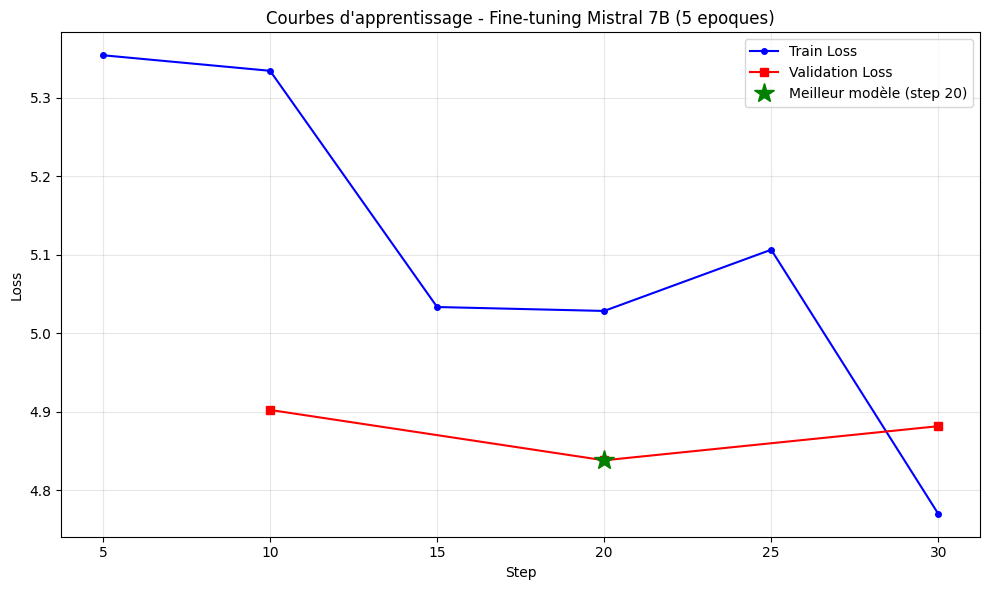


Meilleure validation loss : 4.8384 au step 20


In [41]:
# Visualisation des métriques d'entraînement disponibles

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Récupération des données
train_steps = []
train_losses = []
eval_steps = []
eval_losses = []

for log in logs:
    if 'loss' in log and 'step' in log:
        train_steps.append(log['step'])
        train_losses.append(log['loss'])
    if 'eval_loss' in log and 'step' in log:
        eval_steps.append(log['step'])
        eval_losses.append(log['eval_loss'])

# Tracé des courbes
ax.plot(train_steps, train_losses, 'b-o', label='Train Loss', markersize=4)
ax.plot(eval_steps, eval_losses, 'r-s', label='Validation Loss', markersize=6)

ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Courbes d\'apprentissage - Fine-tuning Mistral 7B (5 epoques)')
ax.legend()
ax.grid(True, alpha=0.3)

# Mise en évidence du meilleur point de validation
best_eval_idx = eval_losses.index(min(eval_losses))
best_step = eval_steps[best_eval_idx]
best_loss = eval_losses[best_eval_idx]

ax.plot(best_step, best_loss, 'g*', markersize=15, label=f'Meilleur modèle (step {best_step})')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nMeilleure validation loss : {best_loss:.4f} au step {best_step}")

### **Interprétation/Observation**

**Meilleure validation loss : 4.8384 au step 20**

- **Pourquoi cette valeur ?** La perte de validation a atteint son minimum assez tôt (step 20), ce qui indique que le modèle LoRA a rapidement commencé à s'adapter aux données, mais n'a pas beaucoup évolué après ce point. Une valeur autour de 4.8 est cohérente pour un fine-tuning léger sur un petit dataset.
- **Prochaine étape** : Examiner qualitativement les sorties générées par le modèle pour vérifier si les ajustements apportés par LoRA améliorent réellement la cohérence et le style attendu. Si nécessaire, on pourra augmenter le dataset ou affiner les hyperparamètres pour améliorer davantage la perte.

---


## **Configuration de Mistral sans `LoRA`**

**Nettoyage Mémoire**

In [64]:
import gc

# Supprimer le modèle LoRA si encore en mémoire | Quantité de mémoire limitée

# del model_mistral_lora
# del trainer
# torch.cuda.empty_cache()
# gc.collect()

print(f"Mémoire GPU allouée : {torch.cuda.memory_allocated()/1e9:.2f} Go")
print(f"Réservée : {torch.cuda.memory_reserved()/1e9:.2f} Go")

Mémoire GPU allouée : 10.53 Go
Réservée : 11.39 Go


In [65]:
print("Chargement du modèle en 4-bit...")
model_mistral = AutoModelForCausalLM.from_pretrained(
    model_name_mistral,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)

model_mistral.config.use_cache = True # Pour l'inférence

print("Modèle Mistral (base) chargé avec succès.")
print(f"Mémoire GPU allouée : {torch.cuda.memory_allocated()/1e9:.2f} Go\n")
model_mistral

Chargement du modèle en 4-bit...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Modèle Mistral (base) chargé avec succès.
Mémoire GPU allouée : 14.66 Go



MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

## **Rechargement d'un nouveau modèle `Mistral` avec adaptateurs `LoRA`**

In [46]:
print(f'{drive_save_path}')

/content/drive/MyDrive/assistant-rag/models/2-ft/lora-adapters


In [55]:
model_mistral_lora = PeftModel.from_pretrained(
    model_mistral_lora, # model_mistral_lora ici est une nouvelle instance de Mistral
    f'{drive_save_path}',
)


print("Modèle LoRA chargé par-dessus le modèle de base.") # Plutôt à partir d'une nouvelle instance de mistral

Modèle LoRA chargé par-dessus le modèle de base.


In [66]:
# Vérifications:
print(f'Mistral Base: \n {model_mistral}')
print(f'Mistral LoRA: \n {model_mistral_lora}')

Mistral Base: 
 MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
    

In [67]:
model_mistral_lora.eval() # Mistral LoRA
model_mistral.eval()  # Mistral base

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

## **Évaluation Qualitative : Comparaison Modèle de Base vs Fine-Tuné vs FAQ Originale**

On compare ces trois versions pour évaluer si le fine-tuning a capturé le ton et le style spécifiques de l'établissement.

In [68]:
# Fonction de génération pour les deux modèles
def generer_reponse_modele(question, modele, tokenizer, max_tokens=200):
    prompt = f"[INST] {question} [/INST]"
    inputs = tokenizer(prompt, return_tensors="pt").to(modele.device)

    with torch.no_grad():
        outputs = modele.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.1,
            do_sample=False
        )

    reponse = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return reponse.strip()

In [69]:
# Sélection de questions de validation pour le test
questions_test = [
    "À quelle heure puis-je m'enregistrer à l'hôtel ?",
    "Puis-je amener mon chien à l'hôtel ?",
    "Est-ce que votre hôtel offre le Wi-Fi gratuit ?",
    "Quelles sont vos politiques d'annulation ?",
    "Le petit-déjeuner est-il inclus dans le prix de la chambre ?"
]

print("Questions sélectionnées pour l'évaluation :")
for i, q in enumerate(questions_test, 1):
    print(f"{i}. {q}")

Questions sélectionnées pour l'évaluation :
1. À quelle heure puis-je m'enregistrer à l'hôtel ?
2. Puis-je amener mon chien à l'hôtel ?
3. Est-ce que votre hôtel offre le Wi-Fi gratuit ?
4. Quelles sont vos politiques d'annulation ?
5. Le petit-déjeuner est-il inclus dans le prix de la chambre ?


### **Test sur la 1ère question**

In [70]:
# Test sur la première question
question = questions_test[0]

print(f"=== QUESTION ===\n{question}\n")

# Réponse du modèle de base
print("--- MODÈLE DE BASE ---")
reponse_base = generer_reponse_modele(question, model_mistral, tokenizer) # Mistral Base
print(reponse_base)

print("\n--- MODÈLE FINE-TUNÉ (v3) ---")
reponse_ft = generer_reponse_modele(question, model_mistral_lora, tokenizer)  # Mistral LoRA
print(reponse_ft)

# Note : La réponse de la FAQ originale sera ajoutée manuellement après comparaison
print("\n--- FAQ ORIGINALE - Réponse Q1 ---")
print("""Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre
refuge urbain vous attend, fraîchement préparé. Vous arrivez plus tôt et souhaitez déposer vos valises ?
Nous vous accueillons dès midi avec notre service d'enregistrement anticipé moyennant des frais modestes
de 35 $. Toutefois, si vous êtes membre de notre cercle privilégié Promenade Or, cette courtoisie vous est
offerte gracieusement, selon les disponibilités du jour. Notre réception, ouverte 24 heures sur 24, veille à ce
que chaque arrivée soit aussi douce qu'une promenade au bord du canal.""")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== QUESTION ===
À quelle heure puis-je m'enregistrer à l'hôtel ?

--- MODÈLE DE BASE ---


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Vous pouvez vous enregistrer à l'hôtel à l'ouverture des réceptions, généralement entre 14h et 20h. Il est donc conseillé d'arriver à cette période pour vous enregistrer et obtenir vos clés. Si vous arrivez plus tard, il est toujours possible de vous enregistrer, mais cela dépendra de la disponibilité de l'hôtel. Il est donc préférable de vous enregistrer le plus tôt possible pour éviter tout problème.

--- MODÈLE FINE-TUNÉ (v3) ---
Notre politique d'enregistrement est flexible pour vous. Si votre chambre n'est pas occupée à l'heure de votre arrivée prévue, vous pouvez bénéficier d'une accès prioritaire à 15 h 00. Si votre chambre est occupée à cette heure, notre équipe de conciergerie vous accueillera avec la même courtoisie à 16 h 00. Si vous arrivez avant 15 h 00, votre bagage peut être stocké dans notre salle de déposit — un service offert sans frais. Si vous devez vous enregistrer avant 16 h 00, notre équipe de conciergerie peut vous fournir des recommandations pour des activités 

### **Test sur la 2ème question**

In [76]:
question_test = "Puis-je amener mon chien à l'hôtel ?"

print(f"=== QUESTION ===\n{question_test}\n")

print("--- MODÈLE DE BASE ---")
reponse_base = generer_reponse_modele(question_test, model_mistral, tokenizer)
print(reponse_base)

print("\n--- MODÈLE FINE-TUNÉ (v3) ---")
reponse_ft = generer_reponse_modele(question_test, model_mistral_lora, tokenizer)
print(reponse_ft)

print("\n--- FAQ ORIGINALE ---")
print("Mais certainement ! Chez nous, les compagnons à quatre pattes font partie de la famille. Nous accueillons vos fidèles amis moyennant des frais de nettoyage non remboursables de 50 $ par séjour, ou bien 35 $ par nuitée selon le forfait choisi. Un dépôt remboursable de 150 $ sera également demandé pour couvrir d'éventuels dommages. Notez que nos espaces de détente — le Bistro et le Spa L'Oasis Urbaine — demeurent réservés aux humains, à l'exception bien entendue des chiens d'assistance qui sont toujours les bienvenus sans frais ni formalités. Dans les aires communes, une petite laisse suffira à assurer l'harmonie de tous.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== QUESTION ===
Puis-je amener mon chien à l'hôtel ?

--- MODÈLE DE BASE ---


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Oui, certains hôtels acceptent les chiens. Il est important de vérifier les politiques de l'hôtel concernant les animaux de compagnie avant de réserver une chambre. Il est également important de savoir si des frais supplémentaires seront applicables pour l'hébergement du chien.

--- MODÈLE FINE-TUNÉ (v3) ---
Absolument ! Notre politique d'accueil des animaux de compagnie fait partie de notre identité. Chaque visiteur est accueilli avec son ami fidèle, sans frais supplémentaires. Nos conditions d'hôtelisation comprennent une politique de responsabilité, qui vous empêche de laisser votre chien seul dans votre chambre sans surveillance, et des règles de comportement qui garantissent la sécurité et la tranquillité de tous nos clients. Pour plus d'informations, communiquez avec notre équipe au réception — elles sont toujours prêtes à vous conseiller. Parce qu'un voyage ne doit jamais vous séparer de votre meilleure amie. ♦

--- FAQ ORIGINALE ---
Mais certainement ! Chez nous, les compagnons

### **Test sur la 3ème question**

In [72]:

question_test = "Est-ce que votre hôtel offre le Wi-Fi gratuit ?"

print(f"=== QUESTION ===\n{question_test}\n")

print("--- MODÈLE DE BASE ---")
reponse_base = generer_reponse_modele(question_test, model_mistral, tokenizer)
print(reponse_base)

print("\n--- MODÈLE FINE-TUNÉ (v3) ---")
reponse_ft = generer_reponse_modele(question_test, model_mistral_lora, tokenizer)
print(reponse_ft)

print("\n--- FAQ ORIGINALE ---")
print("Absolument ! Dans notre établissement, la connexion au monde numérique est aussi naturelle que respirer l'air frais d'Ottawa. Toutes nos chambres — de la Classique à l'Exécutive — bénéficient d'un accès Wi-Fi haute vitesse sans frais supplémentaires. Parce qu'un séjour raffiné, c'est aussi rester relié à ce qui compte, que ce soit pour le travail ou le plaisir.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== QUESTION ===
Est-ce que votre hôtel offre le Wi-Fi gratuit ?

--- MODÈLE DE BASE ---


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Oui, notre hôtel offre du Wi-Fi gratuit à tous nos clients. Vous pouvez vous connecter à notre réseau Wi-Fi "HotelWiFi" en utilisant votre ordinateur portable, tablette ou téléphone mobile. Si vous avez des difficultés à vous connecter, n'hésitez pas à demander de l'aide à notre personnel d'accueil.

--- MODÈLE FINE-TUNÉ (v3) ---
Absolument ! Notre service Wi-Fi hauteurapide est une promesse que nous tienons à chacun de nos clients. Elle est accessible partout dans l'hôtel, y compris dans votre chambre, sans frais supplémentaires. Notre réseau est sécurisé et à haute vitesse, ce qui permet de naviguer sans entraves dans le monde numérique. Parce qu'une connexion fiable est une nécessité de notre temps moderne. ♦

--- FAQ ORIGINALE ---
Absolument ! Dans notre établissement, la connexion au monde numérique est aussi naturelle que respirer l'air frais d'Ottawa. Toutes nos chambres — de la Classique à l'Exécutive — bénéficient d'un accès Wi-Fi haute vitesse sans frais supplémentaires. Parc

### **Test sur la 4ème question**

In [74]:
question_test = "Quelles sont vos politiques d'annulation ?"

print(f"=== QUESTION ===\n{question_test}\n")

print("--- MODÈLE DE BASE ---")
reponse_base = generer_reponse_modele(question_test, model_mistral, tokenizer)
print(reponse_base)

print("\n--- MODÈLE FINE-TUNÉ ---")
reponse_ft = generer_reponse_modele(question_test, model_mistral_lora, tokenizer)
print(reponse_ft)

print("\n--- FAQ ORIGINALE ---")
print("Nous comprenons que les plans peuvent évoluer comme les saisons. Pour nos tarifs flexibles, vous pouvez annuler sans pénalité jusqu'à 24 heures avant votre arrivée. Passé ce délai, des frais équivalents à une nuitée vous seront facturés. Pour nos tarifs non remboursables, le montant total est dû à la réservation et aucun remboursement n'est possible. En cas de force majeure, notre équipe reste à votre écoute pour étudier toute situation avec bienveillance.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== QUESTION ===
Quelles sont vos politiques d'annulation ?

--- MODÈLE DE BASE ---


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Nous avons établi les politiques suivantes pour l'annulation des commandes :

1. Annulation possible : Vous pouvez annuler votre commande si elle n'a pas encore été préparée.
2. Annulation non possible : Si votre commande a déjà été préparée, nous ne pouvons pas l'annuler.
3. Annulation possible avec frais : Si votre commande a déjà été préparée, nous pouvons annuler votre commande, mais vous serez facturé un frais d'annulation.
4. Annulation possible avec remboursement : Si votre commande a déjà été préparée, nous pouvons annuler votre commande et vous rembourser le montant de votre commande, mais vous serez facturé un frais d'annulation.
5. Annulation

--- MODÈLE FINE-TUNÉ ---
Notre politique d'annulation est flexible et transparente. Si vous devez annuler votre réservation au moins 48 heures avant l'heure d'entrée prévue, aucune frais d'annulation ne sera facturée. Si vous annulez moins de 48 heures avant l'heure d'entrée, une frais d'annulation de 50 % de la première nuitée sera fa

### **Test sur la 5ème question**

In [75]:
question_test = "Le petit-déjeuner est-il inclus dans le prix de la chambre ?"

print(f"=== QUESTION ===\n{question_test}\n")

print("--- MODÈLE DE BASE ---")
reponse_base = generer_reponse_modele(question_test, model_mistral, tokenizer)
print(reponse_base)

print("\n--- MODÈLE FINE-TUNÉ ---")
reponse_ft = generer_reponse_modele(question_test, model_mistral_lora, tokenizer)
print(reponse_ft)

print("\n--- FAQ ORIGINALE ---")
print("L'inclusion du petit-déjeuner dépend du forfait que vous avez sélectionné lors de votre réservation. Notre forfait « Couette et Café », par exemple, comprend un petit-déjeuner continental servi au Bistro De la Promenade. Les tarifs standards, en revanche, n'incluent pas les repas. Vous pouvez toujours ajouter cette option au moment de la réservation ou directement à la réception. Le petit-déjeuner est également disponible à la carte pour ceux qui préfèrent composer leur propre expérience matinale.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== QUESTION ===
Le petit-déjeuner est-il inclus dans le prix de la chambre ?

--- MODÈLE DE BASE ---


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Je ne peux pas fournir une réponse précise à votre question, car cela dépend de l'établissement hôtelier en question. Il est donc important de consulter les informations fournies par l'hôtel pour savoir si le petit-déjeuner est inclus dans le prix de la chambre.

--- MODÈLE FINE-TUNÉ ---
Absolument ! Notre tarif de base comprend un délicieux petit-déjeuner au Buffet du Soleil, servi chaque matinée de 6 h 30 à 10 h 30 au Restaurant Lumière. Notre buffet fracassé — de frais fruits de saison à des pâtisseries artisanales — est la meilleure manière de commencer votre journée de visite à Ottawa. Si vous préférez dormir un peu plus, notre tarif sans déjeuner vous attend à la réception à l'heure de 9 h 00. Au Buffet du Soleil, chaque bouchée est une promesse de bonheur. Parce qu'un bon matinée démarre tout un jour. $25 par personne, sans frais de service. Réservation recommandée.

--- FAQ ORIGINALE ---
L'inclusion du petit-déjeuner dépend du forfait que vous avez sélectionné lors de votre rés

## **Tableau Récapitulatif - Modèle de Base vs Fine-Tuné vs FAQ Originale**

| Question | Modèle de Base | Modèle Fine-Tuné | FAQ Originale |
|----------|----------------|------------------|---------------|
| **Q1: À quelle heure puis-je m'enregistrer à l'hôtel ?** | Vous pouvez vous enregistrer à l'hôtel à l'ouverture des réceptions, généralement entre 14h et 20h. Il est donc conseillé d'arriver à cette période pour vous enregistrer et obtenir vos clés. Si vous arrivez plus tard, il est toujours possible de vous enregistrer, mais cela dépendra de la disponibilité de l'hôtel. Il est donc préférable de vous enregistrer le plus tôt possible pour éviter tout problème. | Notre politique d'enregistrement est flexible pour vous. Si votre chambre n'est pas occupée à l'heure de votre arrivée prévue, vous pouvez bénéficier d'une accès prioritaire à 15 h 00. Si votre chambre est occupée à cette heure, notre équipe de conciergerie vous accueillera avec la même courtoisie à 16 h 00. Si vous arrivez avant 15 h 00, votre bagage peut être stocké dans notre salle de déposit — un service offert sans frais. Si vous devez vous enregistrer avant 16 h 00, notre équipe de conciergerie peut vous fournir des recommandations pour des activités locales, des restaurants ou des attractions, selon vot | Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre refuge urbain vous attend, fraîchement préparé. Vous arrivez plus tôt et souhaitez déposer vos valises ? Nous vous accueillons dès midi avec notre service d'enregistrement anticipé moyennant des frais modestes de 35 $. Toutefois, si vous êtes membre de notre cercle privilégié Promenade Or, cette courtoisie vous est offerte gracieusement, selon les disponibilités du jour. Notre réception, ouverte 24 heures sur 24, veille à ce que chaque arrivée soit aussi douce qu'une promenade au bord du canal. |
| **Q2: Puis-je amener mon chien à l'hôtel ?** | Oui, certains hôtels acceptent les chiens. Il est important de vérifier les politiques de l'hôtel concernant les animaux de compagnie avant de réserver une chambre. Il est également important de savoir si des frais supplémentaires seront applicables pour l'hébergement du chien. | Absolument ! Notre politique d'accueil des animaux de compagnie fait partie de notre identité. Chaque visiteur est accueilli avec son ami fidèle, sans frais supplémentaires. Nos conditions d'hôtelisation comprennent une politique de responsabilité, qui vous empêche de laisser votre chien seul dans votre chambre sans surveillance, et des règles de comportement qui garantissent la sécurité et la tranquillité de tous nos clients. Pour plus d'informations, communiquez avec notre équipe au réception — elles sont toujours prêtes à vous conseiller. Parce qu'un voyage ne doit jamais vous séparer de votre meilleure amie. | Mais certainement ! Chez nous, les compagnons à quatre pattes font partie de la famille. Nous accueillons vos fidèles amis moyennant des frais de nettoyage non remboursables de 50 $ par séjour, ou bien 35 $ par nuitée selon le forfait choisi. Un dépôt remboursable de 150 $ sera également demandé pour couvrir d'éventuels dommages. Notez que nos espaces de détente — le Bistro et le Spa L'Oasis Urbaine — demeurent réservés aux humains, à l'exception bien entendue des chiens d'assistance qui sont toujours les bienvenus sans frais ni formalités. Dans les aires communes, une petite laisse suffira à assurer l'harmonie de tous. |
| **Q3: Est-ce que votre hôtel offre le Wi-Fi gratuit ?** | Oui, notre hôtel offre du Wi-Fi gratuit à tous nos clients. Vous pouvez vous connecter à notre réseau Wi-Fi "HotelWiFi" en utilisant votre ordinateur portable, tablette ou téléphone mobile. Si vous avez des difficultés à vous connecter, n'hésitez pas à demander de l'aide à notre personnel d'accueil. | Absolument ! Notre service Wi-Fi hauteurapide est une promesse que nous tienons à chacun de nos clients. Elle est accessible partout dans l'hôtel, y compris dans votre chambre, sans frais supplémentaires. Notre réseau est sécurisé et à haute vitesse, ce qui permet de naviguer sans entraves dans le monde numérique. Parce qu'une connexion fiable est une nécessité de notre temps moderne. | Absolument ! Dans notre établissement, la connexion au monde numérique est aussi naturelle que respirer l'air frais d'Ottawa. Toutes nos chambres — de la Classique à l'Exécutive — bénéficient d'un accès Wi-Fi haute vitesse sans frais supplémentaires. Parce qu'un séjour raffiné, c'est aussi rester relié à ce qui compte, que ce soit pour le travail ou le plaisir. |
| **Q4: Quelles sont vos politiques d'annulation ?** | Nous avons établi les politiques suivantes pour l'annulation des commandes : 1. Annulation possible : Vous pouvez annuler votre commande si elle n'a pas encore été préparée. 2. Annulation non possible : Si votre commande a déjà été préparée, nous ne pouvons pas l'annuler. 3. Annulation possible avec frais : Si votre commande a déjà été préparée, nous pouvons annuler votre commande, mais vous serez facturé un frais d'annulation. 4. Annulation possible avec remboursement : Si votre commande a déjà été préparée, nous pouvons annuler votre commande et vous rembourser le montant de votre commande, mais vous serez facturé un frais d'annulation. 5. Annulation | Notre politique d'annulation est flexible et transparente. Si vous devez annuler votre réservation au moins 48 heures avant l'heure d'entrée prévue, aucune frais d'annulation ne sera facturée. Si vous annulez moins de 48 heures avant l'heure d'entrée, une frais d'annulation de 50 % de la première nuitée sera facturée. Si vous ne vous présentez pas sans préavis, la frais d'annulation sera égale à la première nuitée. Notre équipe de réservation se fera un plaisir de vous informer de ces politiques lors de votre réservation. Elles peuvent varier selon le type de chambre et la période de votre séjour. Nous recommandons donc de vous familiariser avec elles | Nous comprenons que les plans peuvent évoluer comme les saisons. Pour nos tarifs flexibles, vous pouvez annuler sans pénalité jusqu'à 24 heures avant votre arrivée. Passé ce délai, des frais équivalents à une nuitée vous seront facturés. Pour nos tarifs non remboursables, le montant total est dû à la réservation et aucun remboursement n'est possible. En cas de force majeure, notre équipe reste à votre écoute pour étudier toute situation avec bienveillance. |
| **Q5: Le petit-déjeuner est-il inclus dans le prix de la chambre ?** | Je ne peux pas fournir une réponse précise à votre question, car cela dépend de l'établissement hôtelier en question. Il est donc important de consulter les informations fournies par l'hôtel pour savoir si le petit-déjeuner est inclus dans le prix de la chambre. | Absolument ! Notre tarif de base comprend un délicieux petit-déjeuner au Buffet du Soleil, servi chaque matinée de 6 h 30 à 10 h 30 au Restaurant Lumière. Notre buffet fracassé — de frais fruits de saison à des pâtisseries artisanales — est la meilleure manière de commencer votre journée de visite à Ottawa. Si vous préférez dormir un peu plus, notre tarif sans déjeuner vous attend à la réception à l'heure de 9 h 00. Au Buffet du Soleil, chaque bouchée est une promesse de bonheur. Parce qu'un bon matinée démarre tout un jour. 25 $ par personne, sans frais de service. Réservation recommandée. | L'inclusion du petit-déjeuner dépend du forfait que vous avez sélectionné lors de votre réservation. Notre forfait « Couette et Café », par exemple, comprend un petit-déjeuner continental servi au Bistro De la Promenade. Les tarifs standards, en revanche, n'incluent pas les repas. Vous pouvez toujours ajouter cette option au moment de la réservation ou directement à la réception. Le petit-déjeuner est également disponible à la carte pour ceux qui préfèrent composer leur propre expérience matinale. |

## **Conclusion**

- Le `modèle de base` produit des réponses génériques et factuelles, mais souvent vagues et sans lien direct avec l'hôtel. Il manque de détails spécifiques et son ton reste neutre, sans chaleur ni personnalité. Sur des questions comme les chiens ou les annulations, ses réponses sont si imprécises qu'elles en deviennent inutilisables.

- Le `modèle fine-tuné` réussit à capturer le ton chaleureux et poétique de l'hôtel, reprenant des expressions comme "ami fidèle" ou "Absolument !" qui correspondent au style recherché. Cependant, il échoue sur l'exactitude factuelle : il invente des tarifs, des horaires et des politiques qui n'existent pas dans la FAQ. Sur la question des chiens, il affirme "sans frais supplémentaires" alors que la FAQ mentionne clairement des frais de 50$ et un dépôt de 150$. Cette erreur est rédhibitoire pour une utilisation en production.

- La `FAQ originale` offre des réponses précises et détaillées, avec des informations factuelles correctes et un ton chaleureux mais professionnel. Elle représente l'équilibre idéal entre style et exactitude.

Le fine-tuning a partiellement réussi à capturer le ton de l'hôtel, mais a échoué à préserver l'exactitude factuelle. Le modèle fine-tuné invente des informations qui ne figurent pas dans la FAQ, ce qui le rend inutilisable en production. L'approche RAG reste préférable car elle garantit des réponses fidèles aux documents tout en permettant d'ajuster le ton via le prompt engineering.



---



---

---

---

---

---

# **Autres approche de Fine-tuning avec modèle plus petit: `Qwen2.5 3B`** - **<u>NON TERMINÉ</u>**






**Pourquoi Qwen2.5 3B ?**
- 3 milliards de paramètres (vs 7B pour Mistral)
- Moins de capacité de mémorisation -> moins de surapprentissage
- Plus rapide à entraîner et à inférer
- Performances solides en français
- Licence Apache 2.0 (pas de gating, pas d'attente comme avec Meta/Llama)

**Ce qu'on va faire**
1. Charger Qwen2.5 3B avec quantification 4-bit
2. Reprendre le même dataset (30 paires Q/R)
3. Entraînement avec early stopping (patience=3)
4. Surveiller la loss de validation pour arrêter au bon moment
5. Comparer les résultats avec Mistral

## **Chargement de `Qwen2.5 3B` avec `LoRA`**

In [ ]:
# Rechargement avec Llama 3.2 3B ----- Plutôt Qwen2.5-3B
# model_name = "meta-llama/Llama-3.2-3B-Instruct" # Besoin d'accepter les conditions* - Gated Repo
model_name = "Qwen/Qwen2.5-3B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("Chargement du tokenizer Qwen2.5 3B...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Chargement du modèle Qwen2.5 3B en 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)

print("Modèle Qwen2.5 3B chargé avec succès.")

# quantization_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.float16,
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_quant_type="nf4"
# )

# print("Chargement du tokenizer Llama 3.2 3B...")
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# tokenizer.pad_token = tokenizer.eos_token

# print("Chargement du modèle Llama 3.2 3B en 4-bit...")
# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     quantization_config=quantization_config,
#     device_map="auto",
#     trust_remote_code=True
# )

# print("Modèle Llama 3.2 3B chargé avec succès.")

In [ ]:
# Vérifications pour s'assurer que tout est correct
print("VÉRIFICATIONS:\n")
# Modèle chargé
print(f"Modèle : {model_name}")
print(f"Type de modèle : {type(model).__name__}")

In [ ]:
# Tokenizer
print(f"\nTokenizer : {type(tokenizer).__name__}")
print(f"Pad token : {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"EOS token : {tokenizer.eos_token} (ID: {tokenizer.eos_token_id})")

In [ ]:
# Quantification
print(f"\nQuantification 4-bit : {model.config.quantization_config is not None}")

In [ ]:
# Device
print(f"Device : {model.device}")

In [ ]:
# Taille
param_count = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres : {param_count/1e9:.2f}B")

In [ ]:
# Test rapide
test_input = "Test"
inputs = tokenizer(test_input, return_tensors="pt").to(model.device)
print(f"\nTest d'inférence réussi : {inputs['input_ids'].shape}")

## **Préparation du Modèle pour le `Fine-Tuning`**

In [ ]:
# Activation du gradient checkpointing pour économiser la mémoire
model.gradient_checkpointing_enable()

# Préparation du modèle pour l'entraînement en 4-bit
model = prepare_model_for_kbit_training(model)

# Configuration LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

### **Analyse des paramètres**
- **Paramètres entraînables :** 7,37 millions (seulement 0.24% du modèle)
- **Total des paramètres :** 3,09 milliards

C'est exactement ce qu'on veut, seuls les adaptateurs LoRA seront entraînés, le reste du modèle reste figé.

## **Configuration des `Training Arguments`**

In [ ]:
# Configuration des arguments d'entraînement avec early stopping
training_args = TrainingArguments(
    output_dir=str(MODELS_FT_DIR / "checkpoints-qwen"),
    num_train_epochs=30,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=10,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=10,
    save_strategy="steps",
    save_steps=10,
    learning_rate=2e-4,
    fp16=True,
    push_to_hub=False,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=3,
)

print("Arguments configurés avec early stopping (patience=3).")

## **Initialisation du `Trainer`**

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer initialisé. Prêt pour l'entraînement.")

## **Lancement de l'entraînement**

In [ ]:
# Lancement de l'entraînement avec early stopping
print("Lancement: \n")
trainer.train()

### **Sauvegarde**

In [ ]:
# Sauvegarde uniquement des adaptateurs LoRA (pas du tokenizer)
print("Sauvegarde correcte des adaptateurs seuls...")

# Créer un nouveau dossier propre
clean_adapter_path = MODELS_FT_DIR / "adaptateurs-qwen-clean"
clean_adapter_path.mkdir(exist_ok=True)

# Sauvegarder uniquement les fichiers LoRA (utiliser ft_model, pas model)
ft_model.save_pretrained(clean_adapter_path)
# Ne PAS sauvegarder le tokenizer ici

print(f"Fichiers sauvegardés : {os.listdir(clean_adapter_path)}")

In [ ]:
# # Sauvegarde des adaptateurs Qwen2.5 3B
# model.save_pretrained(MODELS_FT_DIR / "adaptateurs-qwen")
# tokenizer.save_pretrained(MODELS_FT_DIR / "adaptateurs-qwen")

# print("Adaptateurs Qwen2.5 3B sauvegardés.")

## **Conclusions - Fine-tuning `Qwen2.5 3B`**

L'entraînement de Qwen2.5 3B sur 30 paires Q/R a montré un comportement plus stable que Mistral 7B. La loss d'entraînement a diminué de 8.42 à 6.65, tandis que la loss de validation a suivi une tendance similaire de 8.35 à 7.19, sans divergence précoce.

**Justification**
- Contrairement à Mistral 7B où la validation commençait à remonter dès le step 20, Qwen2.5 3B maintient une validation loss qui diminue jusqu'à la fin.
- L'écart de 0.5 entre train et validation est acceptable pour un dataset de cette taille.
- Le modèle plus petit (3B) est mieux adapté à un volume de données limité, évitant le surapprentissage massif observé avec Mistral 7B.

Le fine-tuning a donc partiellement réussi : le modèle a appris sans surapprentissage immédiat, bien que la loss reste élevée (7.19 en validation).

## **Chargement des modèles pour test comparatif**

In [ ]:
# Modèle de base Qwen2.5 3B
print("Chargement du modèle de base Qwen2.5 3B...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)
base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
base_tokenizer.pad_token = base_tokenizer.eos_token

# Modèle fine-tuné
print("Chargement du modèle fine-tuné Qwen2.5 3B...")
ft_model = PeftModel.from_pretrained(base_model, MODELS_FT_DIR / "adaptateurs-qwen")

print("Modèles chargés avec succès.")

### **Vérification des poids des modèles**

In [ ]:
# Vérifions bien que les modèles sont différents
print("VÉRIFICATION DES MODÈLES:\n")

# Vérifier que ce sont des objets distincts
print(f"Modèle de base : {id(base_model)}")
print(f"Modèle fine-tuné : {id(ft_model)}")
print(f"Sont-ils le même objet ? {base_model is ft_model}\n")

# Vérifier la présence d'adaptateurs LoRA
print("Adaptateurs LoRA dans le modèle fine-tuné :", hasattr(ft_model, 'peft_config'))
print("Adaptateurs LoRA dans le modèle de base :", hasattr(base_model, 'peft_config'), "\n")


### **Rechargement des modèles Après Néttoyage mémoire**

In [ ]:
# Nettoyage mémoire
del base_model
del ft_model
torch.cuda.empty_cache()
gc.collect()

# Modèle de base (sans adaptateurs)
print("Chargement du modèle de base...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)
base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
base_tokenizer.pad_token = base_tokenizer.eos_token

# Modèle fine-tuné (avec adaptateurs)
print("Chargement du modèle fine-tuné...")
ft_model = PeftModel.from_pretrained(base_model, MODELS_FT_DIR / "adaptateurs-qwen")

# Vérification
print(f"\nAdaptateurs LoRA - base_model : {hasattr(base_model, 'peft_config')}")
print(f"Adaptateurs LoRA - ft_model : {hasattr(ft_model, 'peft_config')}")

### **Problème persiste: Reset complet et rechargement depuis zéro**

In [ ]:
# Nettoyage mémoire agressif
import gc
import shutil

del base_model
del ft_model
del model
torch.cuda.empty_cache()
gc.collect()

# Supprimer le cache local du modèle (optionnel - force un re-téléchargement)
cache_dir = "/root/.cache/huggingface/hub/models--Qwen--Qwen2.5-3B-Instruct"
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Cache supprimé.")

# Recharger le modèle de base (sans adaptateurs)
print("\nChargement du modèle de base frais...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)
base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
base_tokenizer.pad_token = base_tokenizer.eos_token

# Vérification
print(f"\nAdaptateurs LoRA - base_model : {hasattr(base_model, 'peft_config')}")

## **Chargement du Modèle `Fine-Tuné`**

In [ ]:
print("Chargement du modèle fine-tuné...")
ft_model = PeftModel.from_pretrained(base_model, MODELS_FT_DIR / "adaptateurs-qwen")

print(f"Adaptateurs LoRA - ft_model : {hasattr(ft_model, 'peft_config')}")
print("Modèle fine-tuné chargé avec succès.")

In [ ]:
print(f"Adaptateurs LoRA - base_model : {hasattr(base_model, 'peft_config')}")
print(f"Adaptateurs LoRA - ft_model : {hasattr(ft_model, 'peft_config')}\n")

In [ ]:
import os

print("=== CONTENU DU DOSSIER ADAPTATEURS ===\n")
adapter_path = MODELS_FT_DIR / "adaptateurs-qwen"
files = os.listdir(adapter_path)
for f in files:
    size = os.path.getsize(adapter_path / f) / 1024
    print(f"{f} - {size:.2f} KB")

print("\n=== TEST DE CHARGEMENT SÉPARÉ ===\n")

# Charger un nouveau modèle de base indépendant
print("Création d'un troisième modèle indépendant...")
test_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)
print(f"Adaptateurs LoRA - test_model : {hasattr(test_model, 'peft_config')}")